In [5]:
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from scipy.integrate import quad
from scipy import integrate as intg
import sympy as sp
from scipy import stats
from scipy.interpolate import UnivariateSpline
import pandas as pd
from scipy.stats import linregress
from scipy.stats import norm
import os
import seaborn as sns
from matplotlib import pyplot as plt, patches
import scipy
rng = np.random.default_rng()

from scipy.interpolate import CubicSpline

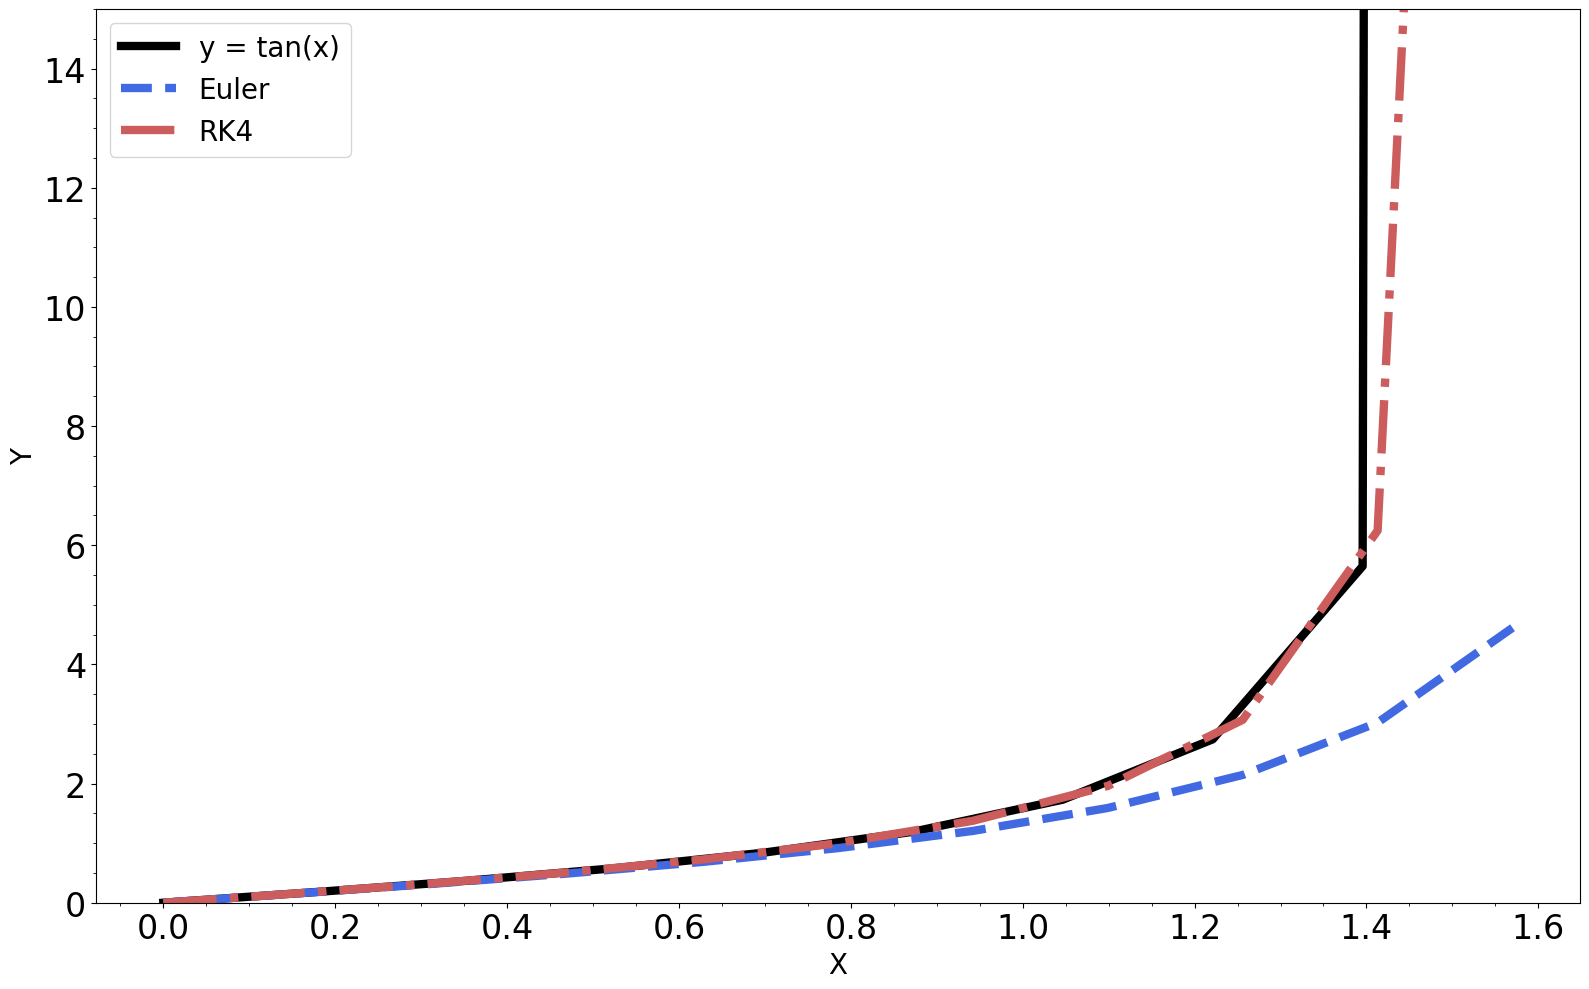

In [23]:
#Problem 1, solving dy/dx = y**2+1 (should have exact soln of tan(x))

ARRR1 = []
BRRR1 = []

def prob1func (x,y):
  return (y**2)+1


def TanFunc (x):
  y = np.tan(x)
  return y

def EulerTest(x0, y0, xn, n):
    h = (xn - x0) / n
    ARRR1, BRRR1 = [x0], [y0]

    # Simple Euler step
    for i in range(n):
        y0 += h * prob1func(x0, y0)
        x0 += h
        ARRR1.append(x0)
        BRRR1.append(y0)

    return ARRR1, BRRR1
def RKtest(x0, y0, xn, n,function):
    h = (xn - x0) / n
    ARRR1, BRRR1 = [x0], [y0]

    for i in range(n):
        k1 = h * function(x0, y0)
        k2 = h * function(x0 + h/2, y0 + k1/2)
        k3 = h * function(x0 + h/2, y0 + k2/2)
        k4 = h * function(x0 + h, y0 + k3)

        k = (k1 + 2*k2 + 2*k3 + k4) / 6
        y0 = y0 + k
        x0 = x0 + h

        ARRR1.append(x0)
        BRRR1.append(y0)

    return ARRR1, BRRR1

#result1 = RKtest(0,1,10,100)
#the solution is 2nd item in the array (or the [1] ojbject in array)
#print (result1[1])

#print ((ARRR1,BRRR1))
#plt.plot(ARRR1,BRRR1)


#x0 is the
x0, y0 = 0.0, 0.0
xn = 1.569999988888
n = 10

x_euler, y_euler = EulerTest(x0, y0, xn, n)
x_rk, y_rk = RKtest(x0, y0, xn, n,prob1func)

x_exact = np.linspace(x0, xn, n)
y_exact = TanFunc(x_exact)

fig, ax = plt.subplots(figsize=(16, 10))

ax.plot(x_exact, y_exact, 'k-', linewidth=6, label='y = tan(x)')
ax.plot(x_euler, y_euler, color='#4169E1', linestyle='--', linewidth=6, label='Euler')
ax.plot(x_rk, y_rk, color='#CD5C5C', linestyle='-.', linewidth=6, label='RK4')

ax.set_ylim(0, 15)
ax.legend(loc='upper left', fontsize = 20)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.minorticks_on()
plt.xlabel("X", fontsize=20)
plt.ylabel("Y", fontsize=20)
plt.tight_layout()
#plt.savefig("Fig2", dpi = 300)
plt.show()

[0.0, 0.03, 0.060027, 0.09013509722186999, 0.12037882729440587, 0.15081355915622915, 0.18149590104499025, 0.21248412390787424, 0.24383860899526116, 0.2756223270123635, 0.30790135702679483, 0.34074545439656306, 0.37422867833732065, 0.40843009144802356, 0.4434345456360308, 0.4793335715239338, 0.5162263917076305, 0.5542210823324949, 0.593435912575549, 0.6340008980455802, 0.6760596122072583, 0.7197713101849932, 0.7653134323539559, 0.8128845718461977, 0.862708011660565, 0.9150359650620647, 0.9701546895827766, 1.0283906932343603, 1.0901183157722918, 1.1557690540437584, 1.2258431172323145, 1.3009238576742896, 1.3816959441782743, 1.468968454643035, 1.5637045042651254, 1.6670596575648966, 1.7804322946213083, 1.9055304692932231, 2.044461860375369, 2.199856589331254, 2.375037659739978, 2.5742617762954727, 2.8030664870823503, 3.0687819390124758, 3.381304616688751, 3.7543012440139707, 4.2071445789381166, 4.768146544180768, 5.480203188184258, 6.411181997697805, 7.674279635925938]
[0.0, 0.03000900303

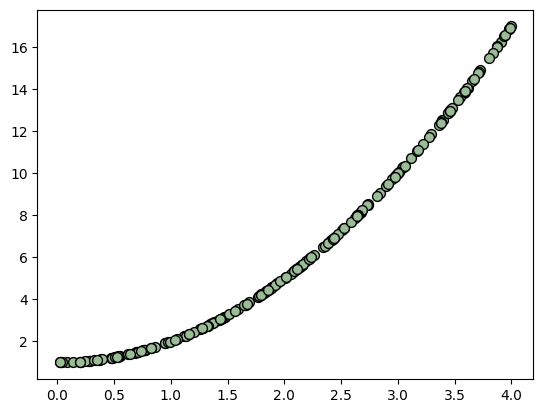

In [9]:
#Prob1 B, where does the solution starrt to break down/what abt the deiv of y(x)?

x0_break, y0 = 0, 0.0
xn = 1.5



n = 50

x_euler, y_euler = EulerTest(x0, y0, xn, n)
x_rk, y_rk = RKtest(x0, y0, xn, n)

print (y_euler)
print (y_rk)


#No matter what value of x I seem to try, I cannot get it to "break down" as the question implies...

#for i in range (10):
  #print (prob1func(0,i))


integerlist = np.random.uniform(low=0, high=4, size=200)
yvallist = []
for i in range (len(integerlist)):
  plotval = prob1func(45,integerlist[i])
  yvallist.append(plotval)
  print(plotval)
yvallist1 = np.array(yvallist)
print (yvallist1)


plt.scatter(integerlist,yvallist1,color = "#9ABD97" ,s = 50, edgecolors='black',label='$f(x) = x^3 - 7x^2 + 14x - 5$')



In [ ]:
#Prob 1 C, increasing/decreasing step size

In [ ]:
45#seeing what scipy gives
ytest = TanFunc(1)
#print (ytest)
integr_test = scipy.integrate.RK45(TanFunc,1,ytest,1)

ValueError: `y0` must be 1-dimensional.

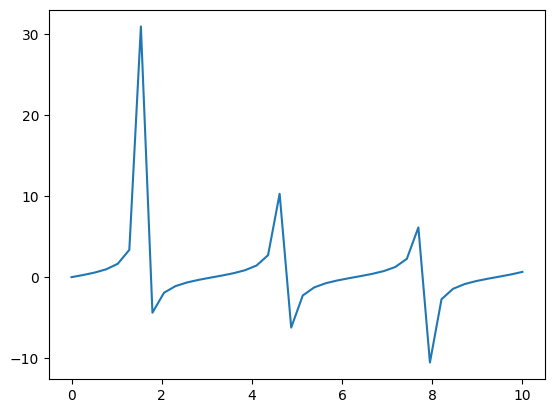

In [ ]:
x = np.linspace(0,10,40)
#print (x)
plt.plot(x, TanFunc(x))

# Question 2 Maxwell botlzman distribution
f(f) dv or can be f(v) = f_v, but it is just df/dv where f is the probability function per dv... so f(v) is our pdf (prob density function) and the f in df/dv is the probability (an integrated quanituty.

Part. you should plot f and it hsould be somewhat gaussian with an exponeital tail


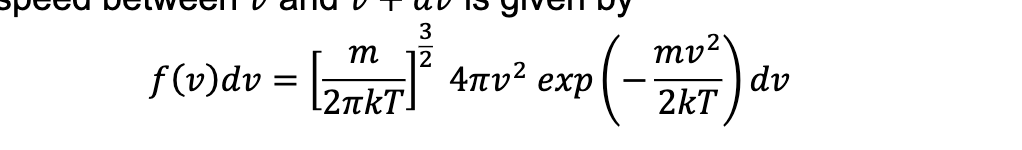

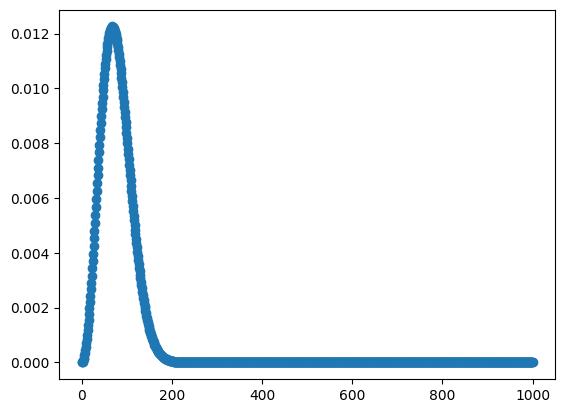

In [28]:
#Defining some constants
Temp = 273.15
k = 1.380649*(10**-23)
v = np.linspace(0, 1000, 1000)  # going from 0-1000m/s
#v = np.linspace(0, 200, 100)
def Maxwell(T,M):


  return ((np.abs(M/(2*np.pi*k*T)))**(3/2))*(4*(np.pi)*(v**2))*(np.exp(-(M*v**2)/(2*k*T)))




test123 = Maxwell(10000,6.02*(10**-23))

#print (test123)
plt.scatter(v,test123)

[1.0, 1.0]


/tmp/ipython-input-710/2994058980.py:9: RuntimeWarning: invalid value encountered in multiply
  return ((np.abs(M/(2*np.pi*k*T)))**(3/2))*(4*(np.pi)*(v**2))*(np.exp(-(M*v**2)/(2*k*T)))


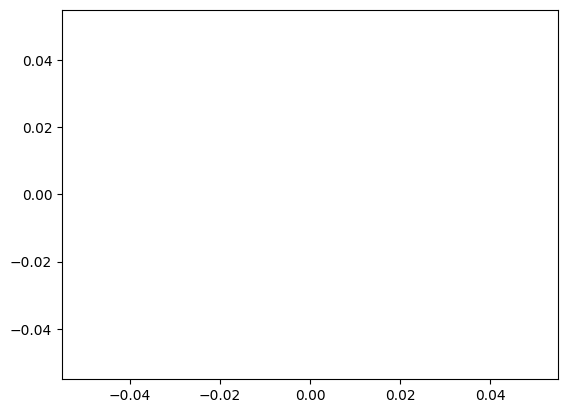

In [39]:
x_maxwell, y_maxwell = 1.0, np.inf
xn_maxwell = 1
n = 1000


x_maxwellout, y_maxwellout = RKtest(x_maxwell, y_maxwell, xn, xn_maxwell,Maxwell)
print (x_maxwellout)
plt.scatter(x_maxwell,y_maxwell)